# 🛍️ Mall Customer Segmentation Analysis

## Project Overview
This project explores the **Mall Customers** dataset, which contains information on 200 shopping mall customers:
Gender, Age, Annual Income (k$), and Spending Score (1-100).

The analysis has two main parts:

1. **Exploratory Data Analysis (EDA):** examine the distribution of each variable, compare customer groups by gender and age, and build an initial understanding of purchasing behavior.
2. **Customer Segmentation:** using a simple rule-based approach as well as the **K-Means** clustering algorithm, customers are grouped into meaningful segments (e.g. high income / low spending, low income / high spending, etc.) so that different marketing strategies can be designed for each segment.

> Note: the CSV path in this notebook is set for the Kaggle environment (`/kaggle/input/mall-customers/Mall_Customers.csv`). If you're running this elsewhere, update the path to match where the file is stored.


## 1. Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the dataset

In [2]:
df= pd.read_csv('Mall_Customers.csv')

### Preview the first few rows to get familiar with the columns

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Check data types and non-null counts for each column

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### Descriptive statistics for the numeric variables (mean, std, min, max)

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Check for missing values

In [6]:
df.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Check for duplicate records

In [7]:
df.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis (EDA)

### Frequency distribution of customer gender

In [9]:
df['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

### Percentage share of each gender

In [10]:
df['Genre'].value_counts(normalize=True) *100

Genre
Female    56.0
Male      44.0
Name: proportion, dtype: float64

### Descriptive statistics for Age

In [35]:
df['Age'].describe()

count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64

### Kernel density plot of customer age

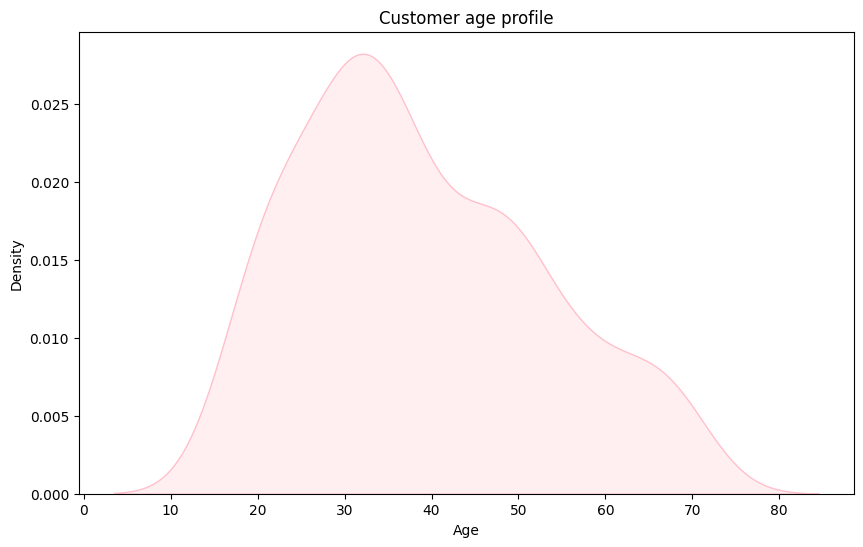

In [11]:
plt.figure(figsize=(10,6))
sns.kdeplot(df['Age'],fill=True, color='pink')
plt.title('Customer age profile')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

### Descriptive statistics for Annual Income

In [34]:
df['Annual Income (k$)'].describe()

count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64

### Kernel density plot of annual income

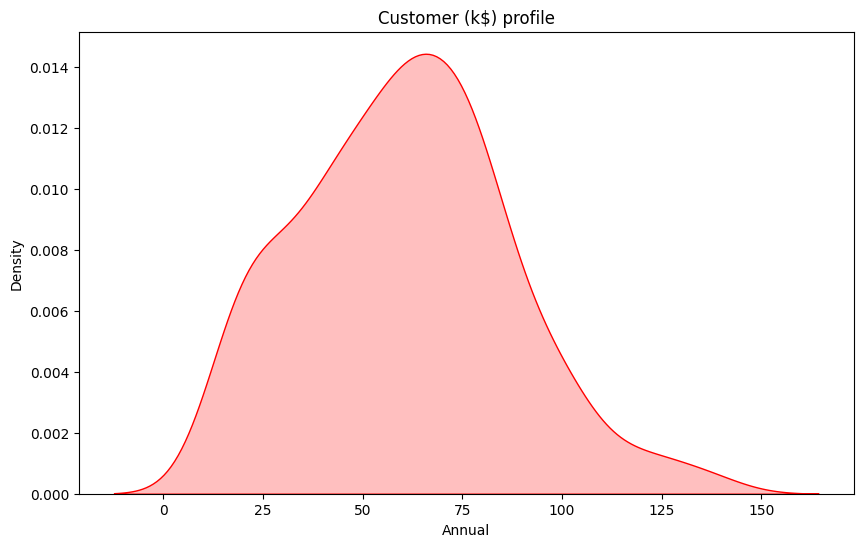

In [12]:
plt.figure(figsize=(10,6))
sns.kdeplot(df['Annual Income (k$)'],fill=True, color='red')
plt.title('Customer (k$) profile')
plt.xlabel('Annual')
plt.ylabel('Density')
plt.show()

### Descriptive statistics for Spending Score

In [33]:
df['Spending Score (1-100)'].describe()

count    200.000000
mean      50.200000
std       25.823522
min        1.000000
25%       34.750000
50%       50.000000
75%       73.000000
max       99.000000
Name: Spending Score (1-100), dtype: float64

### Kernel density plot of spending score

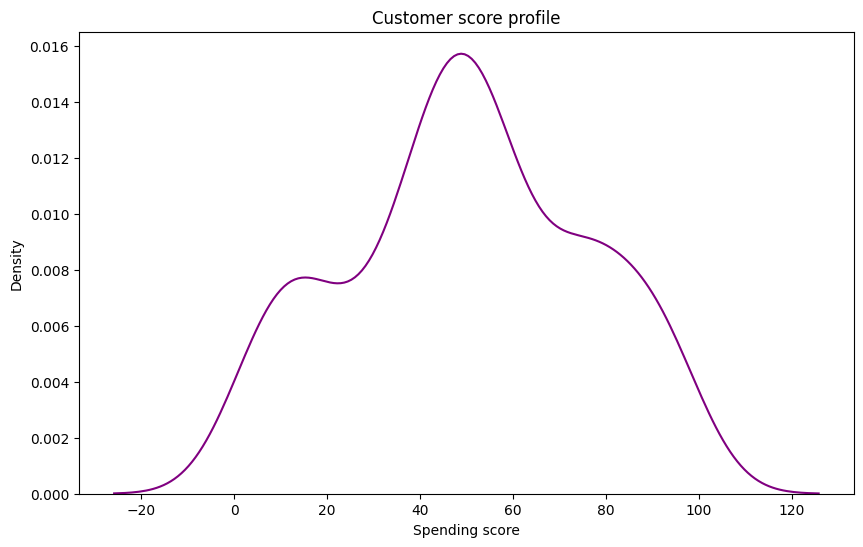

In [13]:
plt.figure(figsize=(10,6))
sns.kdeplot(df['Spending Score (1-100)'],fill=False, color='purple')
plt.title('Customer score profile')
plt.xlabel('Spending score')
plt.ylabel('Density')
plt.show()

## 4. Comparing variables by gender

### Average age by gender

In [15]:
df.groupby(['Genre'])['Age'].mean()

Genre
Female    38.098214
Male      39.806818
Name: Age, dtype: float64

### Boxplot of age by gender

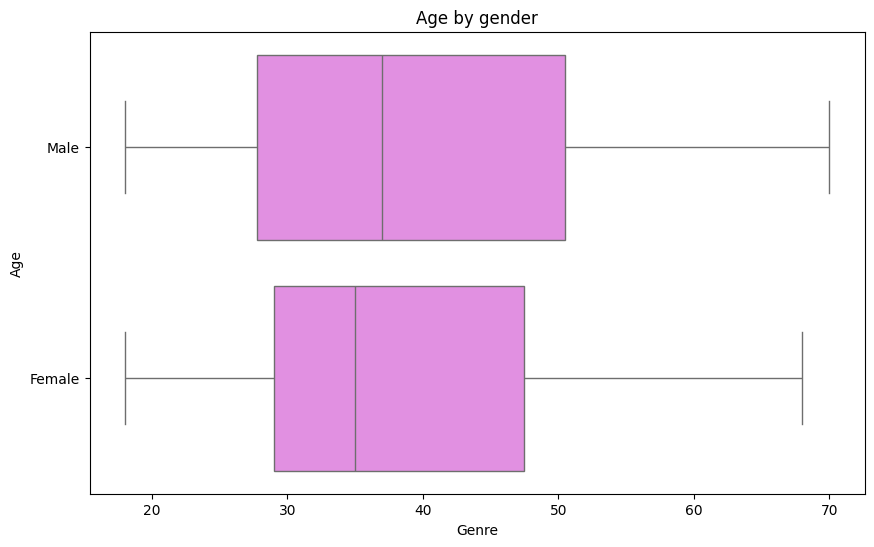

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Age',y='Genre',color='violet')
plt.title('Age by gender')
plt.xlabel('Genre')
plt.ylabel('Age')
plt.show()

### Average annual income by gender

In [16]:
df.groupby(['Genre'])['Annual Income (k$)'].mean()

Genre
Female    59.250000
Male      62.227273
Name: Annual Income (k$), dtype: float64

### Boxplot of annual income by gender

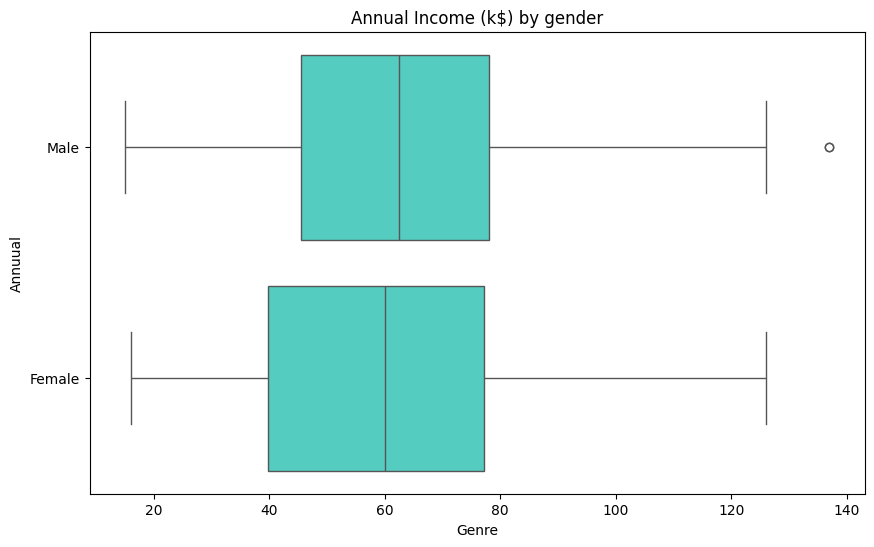

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Annual Income (k$)',y='Genre',color='turquoise')
plt.title('Annual Income (k$) by gender')
plt.xlabel('Genre')
plt.ylabel('Annuual')
plt.show()

### Average spending score by gender

In [32]:
df.groupby(['Genre'])['Spending Score (1-100)'].mean()

Genre
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64

### Boxplot of spending score by gender

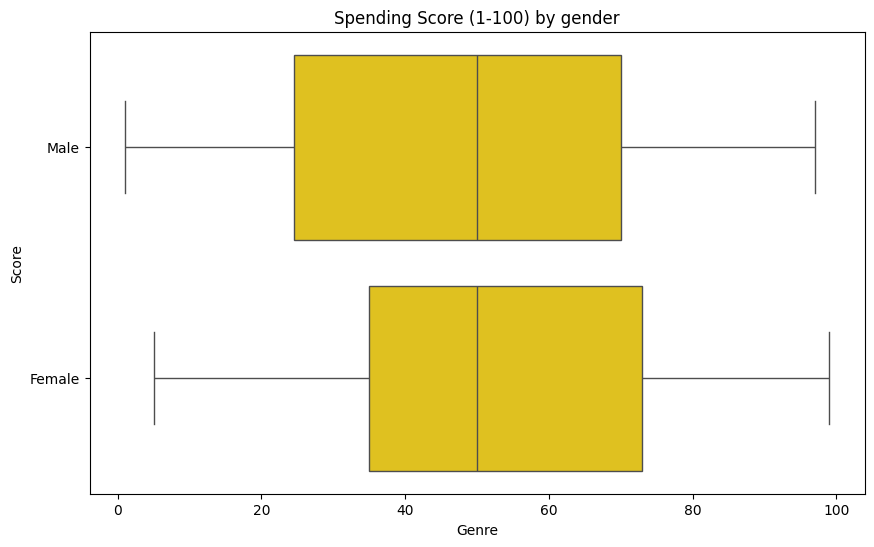

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Spending Score (1-100)',y='Genre',color='Gold')
plt.title('Spending Score (1-100) by gender')
plt.xlabel('Genre')
plt.ylabel('Score')
plt.show()

## 5. Further look at income distribution and its relationship with age

### Histogram of annual income distribution

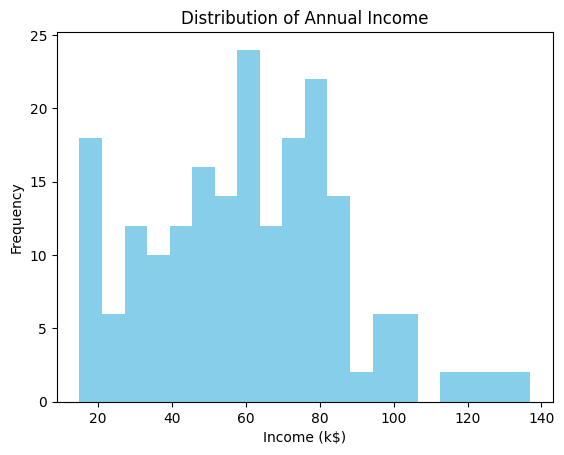

In [31]:
plt.hist(df['Annual Income (k$)'], bins=20, color='skyblue')
plt.title('Distribution of Annual Income')
plt.xlabel('Income (k$)')
plt.ylabel('Frequency')
plt.show()

### Average annual income by age

In [19]:
df.groupby(['Age'])['Annual Income (k$)'].mean()

Age
18     51.250000
19     57.000000
20     41.600000
21     38.800000
22     31.333333
23     41.500000
24     39.250000
25     57.666667
26     58.000000
27     63.166667
28     85.250000
29     63.600000
30     76.142857
31     48.375000
32     87.181818
33     80.333333
34     79.000000
35     46.666667
36     81.000000
37     65.000000
38     74.500000
39     72.666667
40     61.666667
41    101.000000
42     60.000000
43     65.666667
44     75.500000
45     69.333333
46     59.000000
47     70.166667
48     58.200000
49     51.000000
50     58.600000
51     55.500000
52     55.500000
53     39.500000
54     59.750000
55     57.000000
56     79.000000
57     64.500000
58     54.000000
59     65.250000
60     43.333333
63     56.500000
64     19.000000
65     50.500000
66     63.000000
67     45.500000
68     56.666667
69     44.000000
70     47.500000
Name: Annual Income (k$), dtype: float64

### Average spending score by age

In [20]:
df.groupby(['Age'])['Spending Score (1-100)'].mean()

Age
18    60.000000
19    39.750000
20    40.200000
21    66.800000
22    70.000000
23    63.333333
24    71.500000
25    39.666667
26    54.500000
27    60.333333
28    70.000000
29    76.600000
30    80.285714
31    63.875000
32    66.000000
33    54.333333
34    39.200000
35    63.888889
36    52.500000
37    15.333333
38    63.166667
39    84.666667
40    47.500000
41    28.000000
42    18.500000
43    34.000000
44    13.500000
45    37.666667
46    21.333333
47    28.500000
48    41.800000
49    42.714286
50    45.800000
51    46.500000
52    21.000000
53    25.000000
54    35.750000
55    58.000000
56    35.000000
57    28.000000
58    15.000000
59    33.000000
60    36.333333
63    47.000000
64     3.000000
65    43.500000
66    49.000000
67    41.500000
68    48.666667
69    46.000000
70    55.500000
Name: Spending Score (1-100), dtype: float64

## 6. Categorizing customers by Spending Level

Using a simple rule, each customer's spending score is bucketed into three levels: **Low**, **Medium**, and **High**.

In [21]:
def spending_level(score):
    if score < 40:
        return "Low"
    elif score >= 40 and score < 70:
        return "Medium"
    else:
        return "High"

df['Spending_Level'] = df['Spending Score (1-100)'].apply(spending_level)

In [30]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Spending_Level,Cluster
0,1,Male,19,15,39,Low,4
1,2,Male,21,15,81,High,2
2,3,Female,20,16,6,Low,4
3,4,Female,23,16,77,High,2
4,5,Female,31,17,40,Medium,4


### Number of customers in each spending level

In [22]:
levels = ['Low', 'Medium', 'High']

for level in levels:
    count = len(df[df['Spending_Level'] == level])
    print(level, ":", count)

Low : 59
Medium : 87
High : 54


## 7. Correlation between numeric variables

Before moving on to clustering, it's worth checking how the numeric variables (Age, Income, Spending Score) relate to one another.

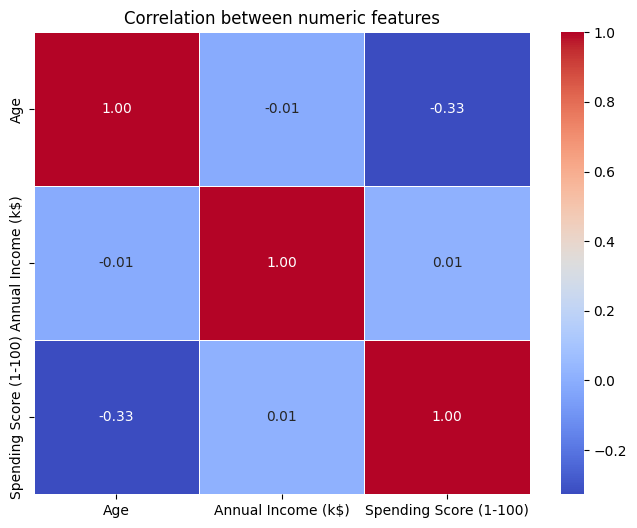

In [23]:
plt.figure(figsize=(8,6))
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between numeric features')
plt.show()

### Pairplot of numeric variables, colored by gender

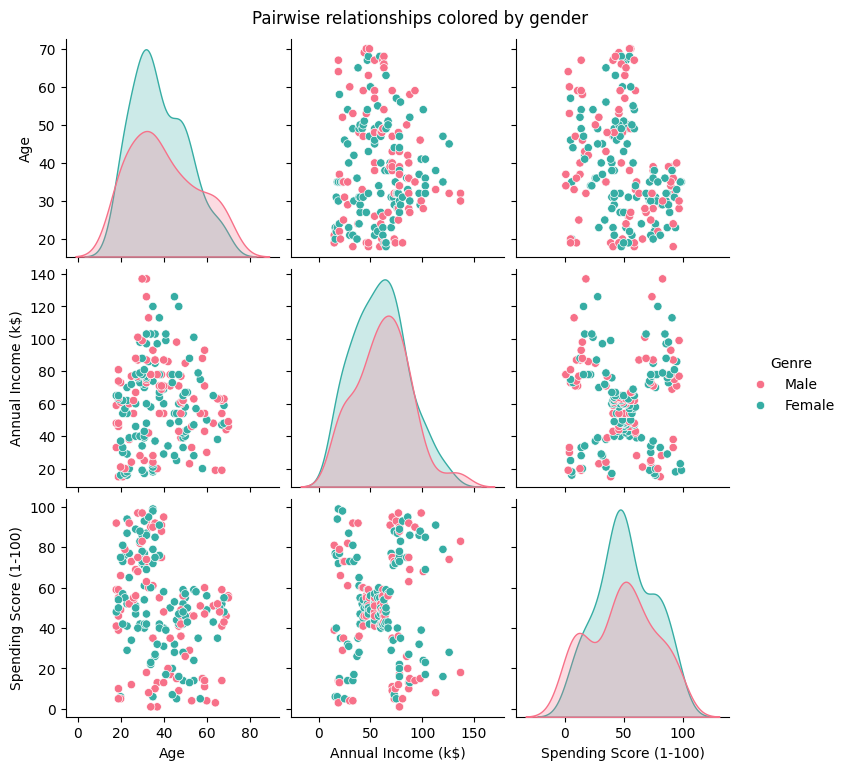

In [24]:
sns.pairplot(df, vars=numeric_cols, hue='Genre', palette='husl', diag_kind='kde')
plt.suptitle('Pairwise relationships colored by gender', y=1.02)
plt.show()

### Scatter plot: Annual Income vs Spending Score

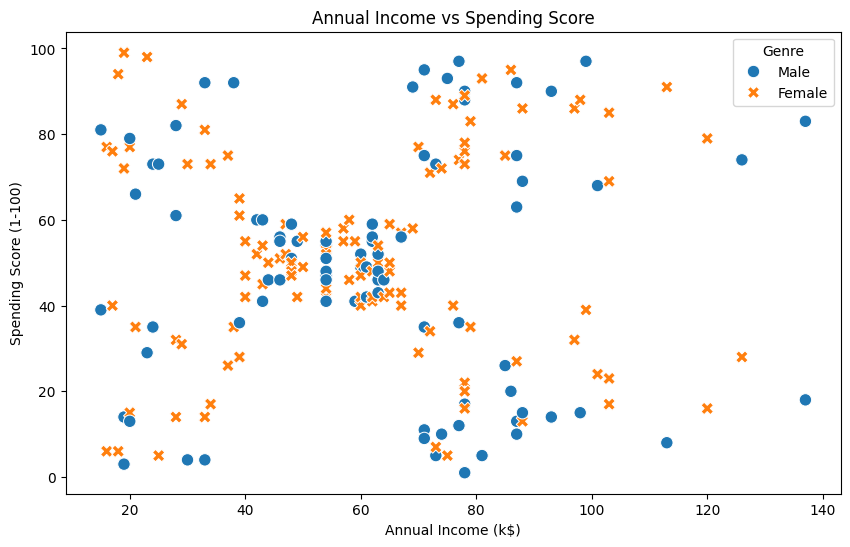

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', style='Genre', s=80)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Genre')
plt.show()

## 8. Customer Segmentation with K-Means

The previous scatter plot shows an interesting relationship between **Annual Income** and **Spending Score**, with visually distinguishable groups in the data.
Now we use the **K-Means** algorithm to extract these groups statistically.

First, we use the **Elbow Method** to estimate a good number of clusters (k).

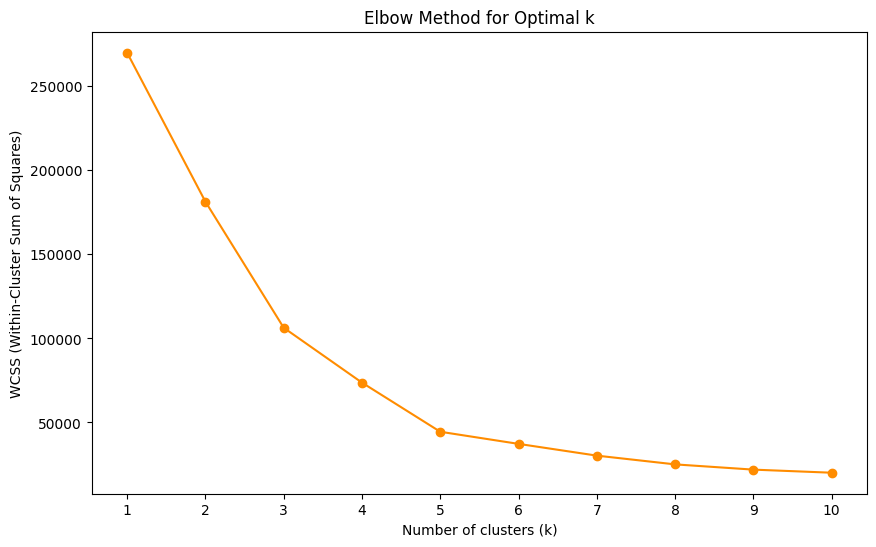

In [26]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(list(k_range), wcss, marker='o', color='darkorange')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.show()

Based on the elbow plot, the bend in the curve typically occurs around **k = 5**.
We fit the final model with 5 clusters and add the cluster label back to the dataframe.

In [27]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)
df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head()

,CustomerID,Annual Income (k$),Spending Score (1-100),Cluster
0,1,15,39,4
1,2,15,81,2
2,3,16,6,4
3,4,16,77,2
4,5,17,40,4


### Visualizing the customer clusters

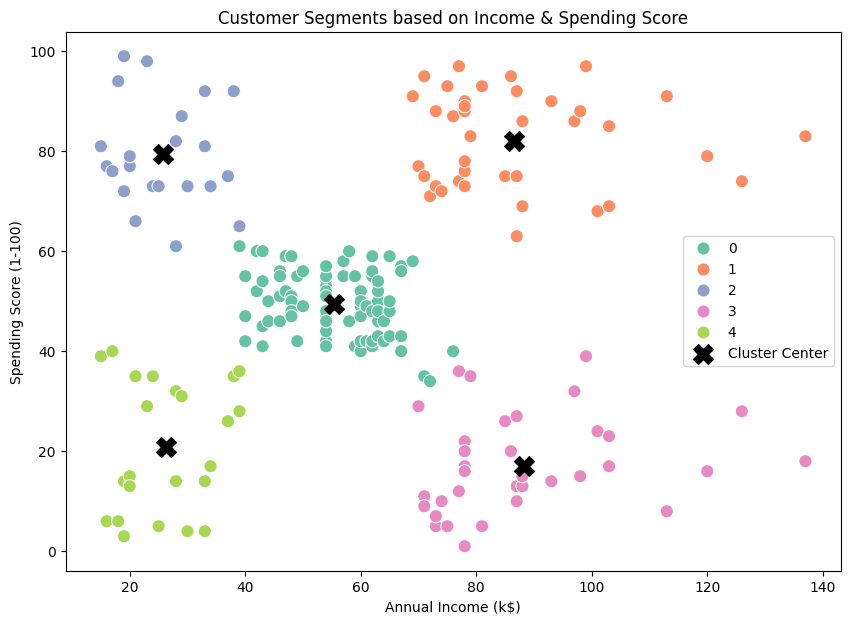

In [28]:
plt.figure(figsize=(10,7))
palette = sns.color_palette('Set2', n_colors=5)
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette=palette, s=90, legend='full'
)
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, marker='X', label='Cluster Center')
plt.title('Customer Segments based on Income & Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

### Statistical summary of each cluster

In [29]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary['Count'] = df['Cluster'].value_counts()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


## 9. Conclusion

Based on this analysis:

- There's no simple linear correlation between annual income and spending score; instead, the data splits into several **distinct behavioral groups** (e.g. high income but low spending, or low income but high spending).
- K-Means clustering separates these groups well and can serve as the basis for designing **targeted marketing campaigns** for each customer segment.
- Gender alone doesn't create a large, meaningful difference in age, income, or spending score; income and spending behavior are more important criteria than gender for customer segmentation.

> As a next step, age could be added to the clustering (3D clustering), or other methods like Hierarchical Clustering could be used to deepen this analysis.